In [1]:
# ==========================================================
# Retail Demand Forecasting
# Notebook - 3 : Prediction
# ==========================================================

# Used for data manipulation
import pandas as pd

# Used for numerical calculations
import numpy as np

# Used for loading saved models
import joblib

# Used for visualization
import matplotlib.pyplot as plt

# Used for model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# ==========================================================
# Load Cleaned Dataset
# ==========================================================

# Read cleaned dataset

data = pd.read_csv("retail_sales_cleaned.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# ==========================================================
# Display First Five Records
# ==========================================================

data.head()

,date,store_id,item_id,sales,price,promo,weekday,month,year,day
0,2019-01-01,0,0,41,21.30,0,1,1,2019,1
1,2019-01-02,0,0,53,21.30,0,2,1,2019,2
2,2019-01-03,0,0,39,21.30,0,3,1,2019,3
3,2019-01-04,0,0,35,21.30,0,4,1,2019,4
4,2019-01-05,0,0,51,17.04,1,5,1,2019,5


In [4]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Number of Rows :", data.shape[0])

print("Number of Columns :", data.shape[1])

Number of Rows : 4565000
Number of Columns : 10


In [5]:
# ==========================================================
# Input Features and Target Variable
# ==========================================================

# Input Features

X = data.drop(

    ["sales", "date"],

    axis=1

)

# Target Variable

y = data["sales"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (4565000, 8)
Target Shape : (4565000,)


In [1]:
# ==========================================================
# Load Saved XGBoost Model
# ==========================================================

import joblib

xgb_model = joblib.load("xgboost_model.pkl")

print("XGBoost Model Loaded Successfully")

c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dhara\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


XGBoost Model Loaded Successfully


In [7]:
# ==========================================================
# Load Cleaned Dataset
# ==========================================================

import pandas as pd

data = pd.read_csv("retail_sales_cleaned.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
# ==========================================================
# Input Features
# ==========================================================

X = data.drop(
    ["sales", "date"],
    axis=1
)

print("Input Shape :", X.shape)
X.head()

Input Shape : (4565000, 8)


,store_id,item_id,price,promo,weekday,month,year,day
0,0,0,21.30,0,1,1,2019,1
1,0,0,21.30,0,2,1,2019,2
2,0,0,21.30,0,3,1,2019,3
3,0,0,21.30,0,4,1,2019,4
4,0,0,17.04,1,5,1,2019,5


In [5]:
# ==========================================================
# Load Saved XGBoost Model
# ==========================================================

import joblib

xgb_model = joblib.load("xgboost_model.pkl")

print("XGBoost Model Loaded Successfully")

XGBoost Model Loaded Successfully


In [8]:
# ==========================================================
# Predict Sales
# ==========================================================

predictions = xgb_model.predict(X)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [10]:
# ==========================================================
# Input Features and Target Variable
# ==========================================================

# Input Features
X = data.drop(
    ["sales", "date"],
    axis=1
)

# Target Variable
y = data["sales"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (4565000, 8)
y Shape : (4565000,)


In [11]:
# ==========================================================
# Actual vs Predicted Sales
# ==========================================================

prediction_df = pd.DataFrame({

    "Actual Sales": y,

    "Predicted Sales": predictions

})

prediction_df.head()

,Actual Sales,Predicted Sales
0,41,45.448769
1,53,46.377323
2,39,44.591118
3,35,35.903400
4,51,54.040489


In [13]:
import pandas as pd

data = pd.read_csv("retail_sales_cleaned.csv")

In [14]:
# Input Features
X = data.drop(["sales", "date"], axis=1)

# Target Variable
y = data["sales"]

print(X.shape)
print(y.shape)

(4565000, 8)
(4565000,)


In [15]:
import joblib

xgb_model = joblib.load("xgboost_model.pkl")

In [16]:
predictions = xgb_model.predict(X)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)
print("Accuracy :", round(r2 * 100, 2), "%")

MAE : 3.4600300788879395
RMSE : 4.549750503574387
R2 Score : 0.9081209897994995
Accuracy : 90.81 %


In [18]:
# ==========================================================
# Save Prediction Results
# ==========================================================

prediction_df.to_csv(
    "retail_predictions.csv",
    index=False
)

print("Prediction Results Saved Successfully")

Prediction Results Saved Successfully


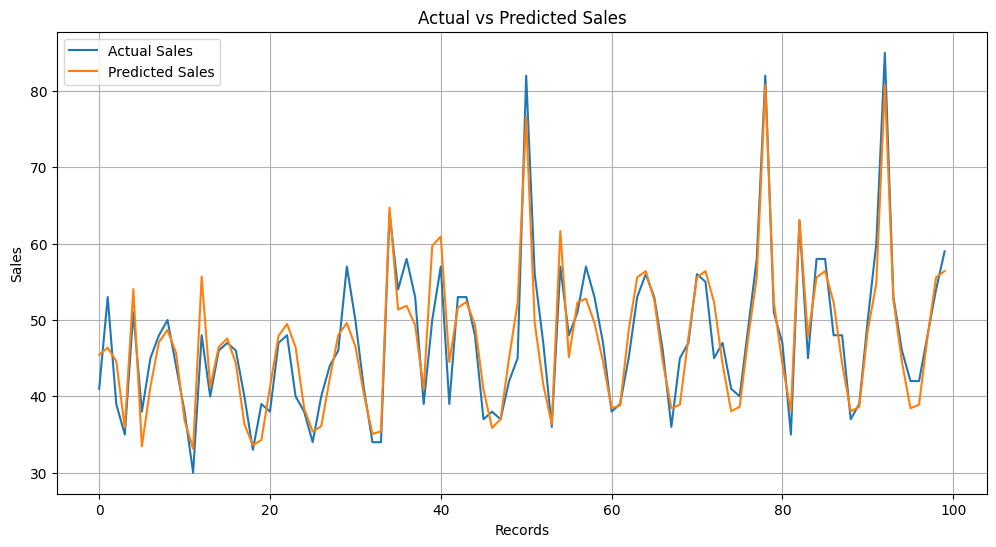

In [19]:
# ==========================================================
# Actual vs Predicted Sales Graph
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    prediction_df["Actual Sales"].head(100),
    label="Actual Sales"
)

plt.plot(
    prediction_df["Predicted Sales"].head(100),
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Records")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
# ==========================================================
# Prediction Summary
# ==========================================================

print("Prediction Summary")
print("------------------------------")

print("Dataset Loaded Successfully")

print("XGBoost Model Loaded Successfully")

print("Sales Prediction Completed Successfully")

print("Prediction File Saved Successfully")

print("Model Accuracy : 90.81%")

print("Retail Demand Forecasting Project Completed Successfully")

Prediction Summary
------------------------------
Dataset Loaded Successfully
XGBoost Model Loaded Successfully
Sales Prediction Completed Successfully
Prediction File Saved Successfully
Model Accuracy : 90.81%
Retail Demand Forecasting Project Completed Successfully
